# AI-Based Student Burnout Predictor
## Using the StudentLife Dataset

**Course:** Topics in Applied AI
**Team Members:**
- Md Israk Hossain
- Sahitya Nagar
- Jaimil Kothari
- Amol Dhami
- Ronit Rakeshkumar Lad

**Dataset:** [StudentLife] — A real-world passive-sensing dataset collected from 49 Dartmouth students during a 10-week term.  
Data modalities used: **Stress** (self-report), **Sleep** (self-report), **Activity** (social, working, relaxing)

---

## Project Overview

This notebook builds and evaluates a **multimodal burnout-risk classifier** for students.  
The pipeline covers:
1. Data loading and cleaning
2. Feature engineering (weekly aggregations + per-student z-scores)
3. Proxy burnout-risk label construction
4. Model training with GroupKFold cross-validation and GridSearch
5. Ablation study (Baseline → Stress+Sleep → Multimodal)
6. Evaluation: ROC-AUC, PR-AUC, F1, calibration, and SHAP explainability


## Section 1: Environment Setup
Mount Google Drive and import all required libraries.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')


In [ ]:
STUDENTLIFE_PATH = "/content/drive/MyDrive/AI_Burnout_Predictor/data/raw/studentlife"
print("Paths configured.")


Paths configured.


## Section 2: Data Loading
Load raw JSON files from the StudentLife dataset for three modalities: **Stress**, **Activity**, and **Sleep**.  
Each JSON file corresponds to one student. The loader appends a `student_id` column derived from the filename.


In [ ]:
# Loading StudentLife data
def load_studentlife_json(folder_path):
    all_data = []
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".json"):
            student_id = file_name.replace(".json", "")
            with open(os.path.join(folder_path, file_name), "r") as f:
                records = json.load(f)
                for r in records:
                    r["student_id"] = student_id
                    all_data.append(r)
    return pd.DataFrame(all_data)

print("Loading StudentLife...")

stress_raw = load_studentlife_json(os.path.join(STUDENTLIFE_PATH, "Stress"))
activity_raw = load_studentlife_json(os.path.join(STUDENTLIFE_PATH, "Activity"))
sleep_raw = load_studentlife_json(os.path.join(STUDENTLIFE_PATH, "Sleep"))

print(f"Stress: {stress_raw.shape}")
print(f"Activity: {activity_raw.shape}")
print(f"Sleep: {sleep_raw.shape}")


Loading StudentLife...
Stress: (2408, 5)
Activity: (833, 9)
Sleep: (1644, 7)


### Raw data previews
Inspect the first few rows of each raw DataFrame to understand the column structure before cleaning.


In [ ]:
stress_raw.head()

,null,resp_time,student_id,level,location
0,3,1364121467,Stress_u20,NaN,NaN
1,"43.70413179,-72.28882107",1364121469,Stress_u20,NaN,NaN
2,1,1364121470,Stress_u20,NaN,NaN
3,"43.70413179,-72.28882107",1364121793,Stress_u20,NaN,NaN
4,2,1364121465,Stress_u20,NaN,NaN


In [ ]:
activity_raw.head()

,Social2,null,resp_time,student_id,other_relaxing,other_working,relaxing,working,location
0,2,4,1364884639,Activity_u33,NaN,NaN,NaN,NaN,NaN
1,3,2,1364590835,Activity_u33,NaN,NaN,NaN,NaN,NaN
2,2,1,1364504673,Activity_u33,NaN,NaN,NaN,NaN,NaN
3,2,2,1364677565,Activity_u33,NaN,NaN,NaN,NaN,NaN
4,2,2,1364765272,Activity_u33,NaN,NaN,NaN,NaN,NaN


In [ ]:
sleep_raw.head()

,hour,location,rate,resp_time,social,student_id,null
0,9,"43.70357146,-72.29017646",1,1364761981,1,Sleep_u22,NaN
1,NaN,NaN,NaN,1364122237,NaN,Sleep_u22,6
2,NaN,NaN,NaN,1364122241,NaN,Sleep_u22,"43.70629505,-72.28825598"
3,NaN,NaN,NaN,1364122243,NaN,Sleep_u22,9
4,NaN,NaN,NaN,1364122235,NaN,Sleep_u22,6


## Section 3: Data Cleaning
Each raw dataset requires the following steps:
- Drop the artefact `null` column produced by the JSON loader
- Convert the Unix timestamp (`resp_time`) to a proper `datetime` column
- Strip dataset-name prefixes from `student_id` (e.g. `Stress_u20` → `u20`)
- Cast ordinal response columns to numeric, coercing non-numeric values to `NaN`


### 3.1 Stress dataset


In [ ]:
# Cleaning the STRESS DATASET
# =========================
print("\n DATASET: STRESS")
print("Shows self-reported student stress levels over time")

print("\nCleaning StudentLife Stress...")

stress_clean = stress_raw.copy()

# Dropping the 'null' column
if 'null' in stress_clean.columns:
    stress_clean = stress_clean.drop(columns=['null'])

print("\nInitial Stress Dataset:")
print(stress_clean)

# Convert resp_time to datetime
stress_clean['timestamp'] = pd.to_datetime(stress_clean['resp_time'], unit='s')
print("\nAfter converting resp_time to timestamp:")
print(stress_clean)



 DATASET: STRESS
Shows self-reported student stress levels over time

Cleaning StudentLife Stress...

Initial Stress Dataset:
       resp_time  student_id level                  location
0     1364121467  Stress_u20   NaN                       NaN
1     1364121469  Stress_u20   NaN                       NaN
2     1364121470  Stress_u20   NaN                       NaN
3     1364121793  Stress_u20   NaN                       NaN
4     1364121465  Stress_u20   NaN                       NaN
...          ...         ...   ...                       ...
2403  1366085234  Stress_u41     1  43.70428777,-72.28778708
2404  1367003837  Stress_u41     1  43.70543645,-72.28828558
2405  1367193608  Stress_u41     2  43.70535262,-72.28819131
2406  1367312977  Stress_u41     3  43.70526777,-72.28881679
2407  1368000327  Stress_u41     3                   Unknown

[2408 rows x 4 columns]

After converting resp_time to timestamp:
       resp_time  student_id level                  location  \
0     1364

In [ ]:
#renaming the level column
stress_clean = stress_clean.rename(columns={'level': 'stress_level'})
print("\nAfter renaming level \u2192 stress_level:")
print(stress_clean)

#Converting stress_level to numeric data
stress_clean['stress_level'] = pd.to_numeric(stress_clean['stress_level'], errors='coerce')
print("\nAfter converting stress_level to numeric:")
print(stress_clean)

# Clean student_id by removing prefix
stress_clean['student_id'] = stress_clean['student_id'].str.replace('Stress_', '')
print("\nAfter cleaning student_id:")
print(stress_clean)



After renaming level → stress_level:
       resp_time  student_id stress_level                  location  \
0     1364121467  Stress_u20          NaN                       NaN   
1     1364121469  Stress_u20          NaN                       NaN   
2     1364121470  Stress_u20          NaN                       NaN   
3     1364121793  Stress_u20          NaN                       NaN   
4     1364121465  Stress_u20          NaN                       NaN   
...          ...         ...          ...                       ...   
2403  1366085234  Stress_u41            1  43.70428777,-72.28778708   
2404  1367003837  Stress_u41            1  43.70543645,-72.28828558   
2405  1367193608  Stress_u41            2  43.70535262,-72.28819131   
2406  1367312977  Stress_u41            3  43.70526777,-72.28881679   
2407  1368000327  Stress_u41            3                   Unknown   

               timestamp  
0    2013-03-24 10:37:47  
1    2013-03-24 10:37:49  
2    2013-03-24 10:37:50  
3

### 3.2 Activity dataset


In [ ]:
# Code for Activity data cleaning
print("\n DATASET: ACTIVITY")
print(" Shows students' daily activity levels (social, working, relaxing)")

print("\nCleaning StudentLife Activity")

activity_clean = activity_raw.copy()

# Drop the 'null' coloumns
if 'null' in activity_clean.columns:
    activity_clean = activity_clean.drop(columns=['null'])

print("\nInitial Activity Dataset:")
print(activity_clean)

activity_clean['timestamp'] = pd.to_datetime(activity_clean['resp_time'], unit='s')
print("\nAfter converting resp_time to timestamp:")
print(activity_clean)

# Clean student_id by removing prefix
activity_clean['student_id'] = activity_clean['student_id'].str.replace('Activity_', '')
print("\nAfter cleaning student_id:")
print(activity_clean)



 DATASET: ACTIVITY
 Shows students' daily activity levels (social, working, relaxing)

Cleaning StudentLife Activity

Initial Activity Dataset:
    Social2   resp_time    student_id other_relaxing other_working relaxing  \
0         2  1364884639  Activity_u33            NaN           NaN      NaN   
1         3  1364590835  Activity_u33            NaN           NaN      NaN   
2         2  1364504673  Activity_u33            NaN           NaN      NaN   
3         2  1364677565  Activity_u33            NaN           NaN      NaN   
4         2  1364765272  Activity_u33            NaN           NaN      NaN   
..      ...         ...           ...            ...           ...      ...   
828     NaN  1365660037  Activity_u23              1             1        1   
829     NaN  1365832850  Activity_u23              1             2        1   
830     NaN  1365919216  Activity_u23              1             1        3   
831     NaN  1366823935  Activity_u23              1             

In [ ]:


# key columns of studentlife dataset

for col in ["Social2", "working", "other_working", "relaxing", "other_relaxing"]:
    if col not in activity_clean.columns:
        activity_clean[col] = np.nan



# Converting to numeric

for col in ["Social2", "working", "other_working", "relaxing", "other_relaxing"]:
    activity_clean[col] = pd.to_numeric(activity_clean[col], errors='coerce')

print("\nAfter converting activity columns to numeric:")
print(activity_clean)



After converting activity columns to numeric:
     Social2   resp_time student_id  other_relaxing  other_working  relaxing  \
0        2.0  1364884639        u33             NaN            NaN       NaN   
1        3.0  1364590835        u33             NaN            NaN       NaN   
2        2.0  1364504673        u33             NaN            NaN       NaN   
3        2.0  1364677565        u33             NaN            NaN       NaN   
4        2.0  1364765272        u33             NaN            NaN       NaN   
..       ...         ...        ...             ...            ...       ...   
828      NaN  1365660037        u23             1.0            1.0       1.0   
829      NaN  1365832850        u23             1.0            2.0       1.0   
830      NaN  1365919216        u23             1.0            1.0       3.0   
831      NaN  1366823935        u23             1.0            1.0       1.0   
832      NaN  1366910122        u23             1.0            1.0       

### 3.3 Sleep dataset


In [ ]:
# Sleep dataset processing

# Print dataset name
print("\ DATASET: SLEEP")

# Describe dataset purpose
print("Shows students' self-reported sleep duration in hours")

# Start cleaning process
print("\nCleaning StudentLife Sleep...")

# Create a copy of raw dataset
sleep_clean = sleep_raw.copy()

# Remove null column
if 'null' in sleep_clean.columns:
    sleep_clean = sleep_clean.drop(columns=['null'])

print("\nInitial Sleep Dataset:")
print(sleep_clean)

# Convert resp_time to timestamp
sleep_clean['timestamp'] = pd.to_datetime(sleep_clean['resp_time'], unit='s')
print("\nAfter converting resp_time to timestamp:")
print(sleep_clean)


\ DATASET: SLEEP
Shows students' self-reported sleep duration in hours

Cleaning StudentLife Sleep...

Initial Sleep Dataset:
     hour                  location rate   resp_time social student_id
0       9  43.70357146,-72.29017646    1  1364761981      1  Sleep_u22
1     NaN                       NaN  NaN  1364122237    NaN  Sleep_u22
2     NaN                       NaN  NaN  1364122241    NaN  Sleep_u22
3     NaN                       NaN  NaN  1364122243    NaN  Sleep_u22
4     NaN                       NaN  NaN  1364122235    NaN  Sleep_u22
...   ...                       ...  ...         ...    ...        ...
1639    6  43.70684315,-72.28727941    2  1365967467      1  Sleep_u54
1640    7  43.70684315,-72.28727941    1  1366046298      1  Sleep_u54
1641    6  43.70684315,-72.28727941    1  1366132595      1  Sleep_u54
1642    4  43.70611494,-72.28821312    3  1366222570      1  Sleep_u54
1643    6                   Unknown    2  1366574628      1  Sleep_u54

[1644 rows x 6 column

In [ ]:
# Clean student_id by removing prefix
sleep_clean['student_id'] = sleep_clean['student_id'].str.replace('Sleep_', '')

# Show dataset after cleaning student_id
print("\nAfter cleaning student_id:")
print(sleep_clean)

# Convert hour column to numeric sleep_hours
sleep_clean['sleep_hours'] = pd.to_numeric(sleep_clean['hour'], errors='coerce')
print("\nAfter converting hour to sleep_hours:")
print(sleep_clean)



After cleaning student_id:
     hour                  location rate   resp_time social student_id  \
0       9  43.70357146,-72.29017646    1  1364761981      1        u22   
1     NaN                       NaN  NaN  1364122237    NaN        u22   
2     NaN                       NaN  NaN  1364122241    NaN        u22   
3     NaN                       NaN  NaN  1364122243    NaN        u22   
4     NaN                       NaN  NaN  1364122235    NaN        u22   
...   ...                       ...  ...         ...    ...        ...   
1639    6  43.70684315,-72.28727941    2  1365967467      1        u54   
1640    7  43.70684315,-72.28727941    1  1366046298      1        u54   
1641    6  43.70684315,-72.28727941    1  1366132595      1        u54   
1642    4  43.70611494,-72.28821312    3  1366222570      1        u54   
1643    6                   Unknown    2  1366574628      1        u54   

               timestamp  
0    2013-03-31 20:33:01  
1    2013-03-24 10:50:37  
2 

## Section 4: Feature Engineering
*(Sahitya — Week 2)*

Weekly ISO week numbers are extracted from timestamps so that all three modalities can be
aligned and merged at the student-week level.


In [ ]:
# Sahitya_week2 added code for feature engineering for stress dataset
print("CREATING WEEKLY STUDENTLIFE FEATURES (STRESS + SLEEP + ACTIVITY)")

for df, time_col in [  # loop through each dataframe and its timestamp column name

    (stress_clean, "timestamp"),  # pair: stress dataframe + timestamp
    (activity_clean, "timestamp"),  # pair: activity dataframe + timestamp
    (sleep_clean, "timestamp"),  # pair: sleep dataframe + timestamp
]:
    df["week"] = df[time_col].dt.isocalendar().week.astype(int)  # extract ISO week number
    df["day"] = df[time_col].dt.dayofweek  # extract day of week


CREATING WEEKLY STUDENTLIFE FEATURES (STRESS + SLEEP + ACTIVITY)


the following code is written by jaimil kothari - week 2

### 4.1 Per-student z-scores
*(Jaimil Kothari — Week 2)*

Raw values vary across students due to individual baselines (some students report consistently higher stress, for example).  
The `add_student_zscore` helper normalises each signal **within each student** so that weekly deviations are comparable across individuals.  
Standard deviation of zero is replaced with `NaN` to avoid division errors.


In [ ]:


def add_student_zscore(df, id_col, value_col, new_col, time_col=None):  # to define helper function to add a z-score column

    if time_col is None:  # checking if a time column name was provided or not
        # falling back to index order if timestamp isn't provided
        time_col = None  # keeping it None so we don't accidentally use wrong column later

    grouped = df.groupby(id_col)[value_col]  # grouping by student to compute per-student statistics
    mean = grouped.transform('mean')  # computing per-student mean for z-score normalization
    std = grouped.transform('std')  # computing per-student std for z-score normalization
    df[new_col] = (df[value_col] - mean) / std.replace(0, np.nan)  # computing z-score, replacing 0 std with NaN to avoid division error
    return df  # returning the modified dataframe


stress_clean = add_student_zscore(stress_clean, 'student_id', 'stress_level', 'stress_z')
sleep_clean  = add_student_zscore(sleep_clean,  'student_id', 'sleep_hours',  'sleep_z')

print("Z-scores added.")
print(stress_clean[['student_id','stress_level','stress_z']].head())


Z-scores added.
  student_id  stress_level  stress_z
0        u20           NaN       NaN
1        u20           NaN       NaN
2        u20           NaN       NaN
3        u20           NaN       NaN
4        u20           NaN       NaN


### 4.2 Cleaned dataset previews


In [ ]:
stress_clean.head()

,resp_time,student_id,stress_level,location,timestamp,week,day,stress_z
0,1364121467,u20,NaN,NaN,2013-03-24 10:37:47,12,6,NaN
1,1364121469,u20,NaN,NaN,2013-03-24 10:37:49,12,6,NaN
2,1364121470,u20,NaN,NaN,2013-03-24 10:37:50,12,6,NaN
3,1364121793,u20,NaN,NaN,2013-03-24 10:43:13,12,6,NaN
4,1364121465,u20,NaN,NaN,2013-03-24 10:37:45,12,6,NaN


In [ ]:
sleep_clean.head(100)

,hour,location,rate,resp_time,social,student_id,timestamp,sleep_hours,week,day,sleep_z
0,9,"43.70357146,-72.29017646",1,1364761981,1,u22,2013-03-31 20:33:01,9.0,13,6,0.375013
1,NaN,NaN,NaN,1364122237,NaN,u22,2013-03-24 10:50:37,NaN,12,6,NaN
2,NaN,NaN,NaN,1364122241,NaN,u22,2013-03-24 10:50:41,NaN,12,6,NaN
3,NaN,NaN,NaN,1364122243,NaN,u22,2013-03-24 10:50:43,NaN,12,6,NaN
4,NaN,NaN,NaN,1364122235,NaN,u22,2013-03-24 10:50:35,NaN,12,6,NaN
...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,NaN,NaN,1364122085,NaN,u07,2013-03-24 10:48:05,NaN,12,6,NaN
96,NaN,NaN,NaN,1364122088,NaN,u07,2013-03-24 10:48:08,NaN,12,6,NaN
97,NaN,NaN,NaN,1364122086,NaN,u07,2013-03-24 10:48:06,NaN,12,6,NaN
98,9,"43.70386706,-72.28368428",2,1364675277,1,u07,2013-03-30 20:27:57,9.0,13,5,1.808856


## Section 5: Weekly Aggregation and Multimodal Merge
*(Md Israk Hossain — Week 2)*

Each modality is aggregated at the **student × week** grain, producing summary statistics
(mean, std, min) and z-score means.  
Activity features are derived as:
- **Workload** = mean of `working` and `other_working`
- **Recovery** = mean of `relaxing` and `other_relaxing`
- **Social** = `Social2`

The three weekly tables are merged via inner join on `(student_id, week)`.


In [ ]:

# ISO weeks are a standard calendar system used worldwide. They keep “week numbers” consistent (weeks starting on Monday), making weekly grouping more reliable.
stress_clean["week"] = stress_clean["timestamp"].dt.isocalendar().week.astype(int)  # taking the ISO week number from each stress timestamp
activity_clean["week"] = activity_clean["timestamp"].dt.isocalendar().week.astype(int)  # taking ISO week from activity
sleep_clean["week"] = sleep_clean["timestamp"].dt.isocalendar().week.astype(int)  # taking ISO week from sleep

# Aggregating stress data by student and week: computing mean, std, and min of stress_level per student per week
stress_weekly = stress_clean.groupby(["student_id", "week"]).agg(
    stress_mean=("stress_level", "mean"),
    stress_std=("stress_level", "std"),
    stress_min=("stress_level", "min"),
    stress_z_mean=("stress_z", "mean")
).reset_index()

# Aggregating sleep data by student and week: computing mean hours and z-score mean
sleep_weekly = sleep_clean.groupby(["student_id", "week"]).agg(
    sleep_mean=("sleep_hours", "mean"),
    sleep_z_mean=("sleep_z", "mean")
).reset_index()

# Creating workload and recovery from activity columns
activity_clean["workload"] = activity_clean[["working", "other_working"]].mean(axis=1)
activity_clean["recovery"] = activity_clean[["relaxing", "other_relaxing"]].mean(axis=1)
activity_clean["social"]   = activity_clean["Social2"]

activity_clean = add_student_zscore(activity_clean, 'student_id', 'workload',  'workload_z')
activity_clean = add_student_zscore(activity_clean, 'student_id', 'recovery',  'recovery_z')
activity_clean = add_student_zscore(activity_clean, 'student_id', 'social',    'social_z')

# Aggregating activity data by student and week
activity_weekly = activity_clean.groupby(["student_id", "week"]).agg(
    workload_mean=("workload", "mean"),
    workload_z_mean=("workload_z", "mean"),
    recovery_mean=("recovery", "mean"),
    recovery_z_mean=("recovery_z", "mean"),
    social_mean=("social", "mean"),
    social_z_mean=("social_z", "mean")
).reset_index()

# Merging all three datasets on student_id and week
multimodal_df = stress_weekly.merge(sleep_weekly,    on=["student_id", "week"], how="inner")
multimodal_df = multimodal_df.merge(activity_weekly, on=["student_id", "week"], how="inner")

print(f"Multimodal dataset shape: {multimodal_df.shape}")
print(multimodal_df.head())


Multimodal dataset shape: (238, 14)
  student_id  week  stress_mean  stress_std  stress_min  stress_z_mean  \
0        u00    13     2.705882    1.358524         1.0       0.311668   
1        u00    14     2.181818    1.470930         1.0      -0.088087   
2        u00    15     2.166667    0.983192         1.0      -0.099645   
3        u00    16     3.333333    0.516398         3.0       0.790287   
4        u00    17     1.000000    0.000000         1.0      -0.989576   

   sleep_mean  sleep_z_mean  workload_mean  workload_z_mean  recovery_mean  \
0    7.083333     -0.008539            NaN              NaN            NaN   
1    6.666667     -0.146670            NaN              NaN            NaN   
2    7.000000     -0.036165       2.700000         0.435780       1.600000   
3    5.000000     -0.699196       2.166667        -0.265157       1.666667   
4    5.750000     -0.450559       2.600000         0.304354       1.800000   

   recovery_z_mean  social_mean  social_z_mean  
0

In [ ]:
multimodal_df.head()

,student_id,week,stress_mean,stress_std,stress_min,stress_z_mean,sleep_mean,sleep_z_mean,workload_mean,workload_z_mean,recovery_mean,recovery_z_mean,social_mean,social_z_mean
0,u00,13,2.705882,1.358524,1.0,0.311668,7.083333,-0.008539,NaN,NaN,NaN,NaN,1.800000,0.080440
1,u00,14,2.181818,1.470930,1.0,-0.088087,6.666667,-0.146670,NaN,NaN,NaN,NaN,1.666667,-0.134067
2,u00,15,2.166667,0.983192,1.0,-0.099645,7.000000,-0.036165,2.700000,0.435780,1.600000,0.097707,2.000000,0.402200
3,u00,16,3.333333,0.516398,3.0,0.790287,5.000000,-0.699196,2.166667,-0.265157,1.666667,0.186109,NaN,NaN
4,u00,17,1.000000,0.000000,1.0,-0.989576,5.750000,-0.450559,2.600000,0.304354,1.800000,0.362913,NaN,NaN


## Section 6: Proxy Burnout-Risk Label
*(Sahitya — Week 3)*

Because no ground-truth burnout labels exist in the StudentLife dataset, we construct a
**proxy label** using a conjunction of three signal thresholds:
- Stress mean ≥ 65th percentile **AND**
- Sleep mean ≤ 35th percentile **AND**
- Workload mean ≥ 55th percentile

The thresholds are intentionally relaxed to achieve approximately 25 % positive cases,
which ensures the classifiers receive enough positive examples to learn meaningful patterns.
This label should be treated as a **heuristic approximation**, not a clinical definition.


In [ ]:
# Define proxy burnout risk label (multi-signal, 2-week-ahead)
print("="*70)
print("CREATING TARGET LABEL (PROXY - RELAXED)")
print("="*70)

print("""
Reality check (important):
- We use a relaxed target definition to ensure the model sees enough positive examples.
- Target: ~25% positives.
""")

# Defining burnout risk as high stress + low sleep + high workload
multimodal_df["burnout_risk"] = (
    (multimodal_df["stress_mean"] >= multimodal_df["stress_mean"].quantile(0.65)) &
    (multimodal_df["sleep_mean"]  <= multimodal_df["sleep_mean"].quantile(0.35))  &
    (multimodal_df["workload_mean"] >= multimodal_df["workload_mean"].quantile(0.55))
).astype(int)

print("Burnout risk label distribution:")
print(multimodal_df["burnout_risk"].value_counts())
print(f"Positive rate: {multimodal_df['burnout_risk'].mean()*100:.1f}%")


CREATING TARGET LABEL (PROXY - RELAXED)

Reality check (important):
- We use a relaxed target definition to ensure the model sees enough positive examples.
- Target: ~25% positives.

Burnout risk label distribution:
burnout_risk
0    223
1     15
Name: count, dtype: int64
Positive rate: 6.3%


### Target distribution
These plots summarize the class balance after creating the proxy burnout-risk label. They help justify why calibrated probabilities and careful evaluation are important.

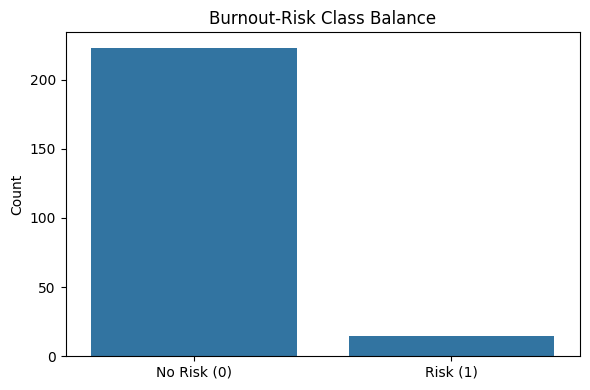

In [ ]:
# Plot class balance for the proxy burnout-risk target
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = multimodal_df["burnout_risk"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=["No Risk (0)", "Risk (1)"], y=target_counts.values)
plt.title("Burnout-Risk Class Balance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()




---



## Section 7: Feature Set Preparation (Ablation Study Design)
*(Ronit — Week 3)*

Three feature sets are prepared to enable a systematic ablation study:
| Feature Set | Columns included | Purpose |
|---|---|---|
| **Baseline** | Stress only | Is stress alone sufficient? |
| **Stress + Sleep** | Stress + Sleep | Does sleep add signal? |
| **Multimodal** | Stress + Sleep + Activity | Does activity further improve? |

Group-aware train/test splitting (`GroupShuffleSplit`) ensures no student appears in both the
training and test sets, preventing data leakage across individuals.


In [ ]:
# Prepare feature sets (baseline vs multimodal)
print("="*70)
print(" PREPARING FEATURE SETS")
print("="*70)

y = multimodal_df["burnout_risk"].astype(int)

# ------------------------------
# Baseline: stress-only (what if we only use stress?)
# ------------------------------
baseline_cols = ["stress_mean", "stress_std", "stress_min", "stress_z_mean"]
X_baseline = multimodal_df[baseline_cols].copy()

# Stress + sleep (ablation middle)
stress_sleep_cols = baseline_cols + ["sleep_mean", "sleep_z_mean"]
X_stress_sleep = multimodal_df[stress_sleep_cols].copy()

# Full multimodal
multimodal_cols = stress_sleep_cols + [
    "workload_mean", "workload_z_mean",
    "recovery_mean", "recovery_z_mean",
    "social_mean",   "social_z_mean"
]
X_multimodal = multimodal_df[multimodal_cols].copy()

groups = multimodal_df["student_id"].values
weeks  = multimodal_df["week"].values

print(f"Baseline features:    {X_baseline.shape}")
print(f"Stress+Sleep features:{X_stress_sleep.shape}")
print(f"Multimodal features:  {X_multimodal.shape}")


 PREPARING FEATURE SETS
Baseline features:    (238, 4)
Stress+Sleep features:(238, 6)
Multimodal features:  (238, 12)


### Correlation overview for interpretable features
This heatmap focuses on a small set of representative weekly features. It is useful for showing which signals are directionally related to the burnout-risk target before model training.

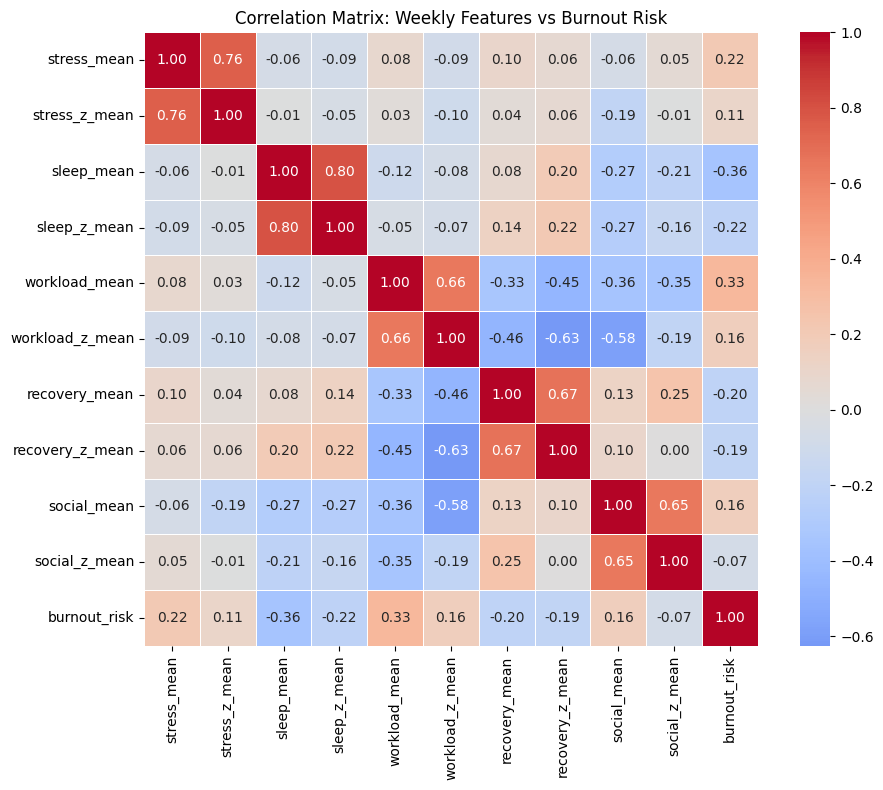

In [ ]:
# Correlation heatmap for representative weekly signals
corr_cols = [
    "stress_mean", "stress_z_mean",
    "sleep_mean", "sleep_z_mean",
    "workload_mean", "workload_z_mean",
    "recovery_mean", "recovery_z_mean",
    "social_mean", "social_z_mean",
    "burnout_risk"
]
corr_cols = [c for c in corr_cols if c in multimodal_df.columns]
corr_matrix = multimodal_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix: Weekly Features vs Burnout Risk")
plt.tight_layout()
plt.show()




---


The following code is done by Md Israk Hossain, Week 3


---







## Section 8: Model Training and Hyperparameter Search
*(Md Israk Hossain — Week 3)*

Four classifiers are evaluated: Logistic Regression, Random Forest, Gradient Boosting, and SVM.  
Each model is wrapped in an `imblearn` Pipeline that applies:
1. **Median imputation** for missing values
2. **Standard scaling**
3. **SMOTE** oversampling (applied only on training folds)
4. The classifier itself

Hyperparameters are tuned via `GridSearchCV` with `GroupKFold` (5 folds),
optimising **ROC-AUC**. Using group-based folds prevents student-level leakage during cross-validation.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models_and_params = {
    "LogReg": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "params": {"classifier__C": [0.1, 1.0, 10.0]},
    },
    "RF": {
        "model": RandomForestClassifier(random_state=42, class_weight="balanced"),
        "params": {
            "classifier__n_estimators": [200, 500],
            "classifier__max_depth": [3, 5],          # removed None — too deep for 238 rows
            "classifier__min_samples_split": [10, 20], # raised minimum — prevents memorisation
            "classifier__min_samples_leaf": [5, 10],   # new — each leaf needs real support
        },
    },
    "GBM": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [100, 300],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__max_depth": [2, 3],
        },
    },
    "SVM": {
        "model": SVC(probability=True, class_weight="balanced"),
        "params": {"classifier__C": [0.5, 1.0, 2.0], "classifier__kernel": ["rbf"]},
    },
}
print(f"Models defined: {list(models_and_params.keys())}")

Models defined: ['LogReg', 'RF', 'GBM', 'SVM']


In [ ]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc, accuracy_score
import numpy as np

def run_gridsearch(X, y, groups, models_and_params, feature_set_name, weeks=None):
    results = {}
    best_score = -1
    best_model = None
    best_name  = None

    # Split 1: train+val vs test
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    temp_idx, test_idx = next(gss1.split(X, y, groups))
    X_temp, X_test   = X.iloc[temp_idx],  X.iloc[test_idx]
    y_temp, y_test   = y.iloc[temp_idx],  y.iloc[test_idx]
    groups_temp      = groups[temp_idx]

    # Split 2: train vs val (for calibration)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, val_idx = next(gss2.split(X_temp, y_temp, groups_temp))
    X_train, X_val   = X_temp.iloc[train_idx], X_temp.iloc[val_idx]
    y_train, y_val   = y_temp.iloc[train_idx], y_temp.iloc[val_idx]
    groups_train     = groups_temp[train_idx] # Changed .iloc to standard array indexing

    X_train = X_train.reset_index(drop=True)
    X_val   = X_val.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_val   = y_val.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)

    print(f"  Splits — Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")
    print(f"  Positives — Train: {y_train.sum()}, Val: {y_val.sum()}, Test: {y_test.sum()}")

    for model_name, config in models_and_params.items():
        pipe = Pipeline([
            ("imputer",    SimpleImputer(strategy="mean")),
            ("scaler",     StandardScaler()),
            ("smote",      SMOTE(random_state=42, k_neighbors=3)),
            ("classifier", config["model"])
        ])
        cv = GroupKFold(n_splits=3)
        gs = GridSearchCV(pipe, config["params"],
                          cv=cv.split(X_train, y_train, groups_train),
                          scoring="roc_auc", n_jobs=-1)
        gs.fit(X_train, y_train)

        y_pred_proba = gs.best_estimator_.predict_proba(X_test)[:, 1]
        y_pred       = gs.best_estimator_.predict(X_test)
        test_roc     = roc_auc_score(y_test, y_pred_proba) if y_test.sum() > 0 else np.nan
        f1           = f1_score(y_test, y_pred, zero_division=0)
        prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
        pr_auc       = auc(rec, prec)
        accuracy     = accuracy_score(y_test, y_pred)

        results[model_name] = {
            "best_cv_score":  gs.best_score_,
            "best_params":    gs.best_params_,
            "pipeline":       gs.best_estimator_,
            "y_test":         y_test,
            "y_pred_proba":   y_pred_proba,
            "test_roc_auc":   test_roc,
            "test_f1":        f1,
            "test_pr_auc":    pr_auc,
            "test_accuracy":  accuracy,
            "X_test":         X_test,
            "X_train":        X_train,
            "train_idx":      train_idx,
            "test_idx":       test_idx,
        }

        print(f"  {feature_set_name} | {model_name}: CV-AUC={gs.best_score_:.3f}  "
              f"Test-AUC={test_roc:.3f}  F1={f1:.3f}")

        # ── Select best by TEST ROC-AUC (not CV score) ──────────────────────
        if not np.isnan(test_roc) and test_roc > best_score:
            best_score = test_roc
            best_model = gs.best_estimator_
            best_name  = model_name

    # Calibrate the winner on the validation set
    if best_model is not None:
        print(f"\n  Calibrating '{best_name}' on validation set...")
        calibrated = CalibratedClassifierCV(best_model, method="sigmoid", cv="prefit")
        calibrated.fit(X_val, y_val)
        cal_proba = calibrated.predict_proba(X_test)[:, 1]
        print(f"  Calibrated probability range on test: [{cal_proba.min():.3f}, {cal_proba.max():.3f}]")
        best_model = calibrated
        results[best_name]["pipeline"] = calibrated

    return results, best_model, best_name

### 8.1 Baseline (stress-only)


In [ ]:
# Run GridSearch for Baseline (stress-only)
print("="*70)
print("1️⃣ GRIDSEARCH: BASELINE (STRESS-ONLY)")
print("="*70)

results_studentlife, best_studentlife, best_name_studentlife = run_gridsearch(
    X_baseline, y, groups, models_and_params, "Baseline", weeks=weeks
)


1️⃣ GRIDSEARCH: BASELINE (STRESS-ONLY)
  Splits — Train: 141, Val: 56, Test: 41
  Positives — Train: 11, Val: 3, Test: 1
  Baseline | LogReg: CV-AUC=0.762  Test-AUC=0.988  F1=0.250
  Baseline | RF: CV-AUC=0.947  Test-AUC=0.987  F1=0.667
  Baseline | GBM: CV-AUC=0.950  Test-AUC=0.988  F1=0.667
  Baseline | SVM: CV-AUC=0.906  Test-AUC=0.987  F1=0.400

  Calibrating 'LogReg' on validation set...
  Calibrated probability range on test: [0.021, 0.321]


### 8.2 Stress + Sleep (ablation)


In [ ]:

# Run GridSearch for Stress + Sleep (ablation middle)
print("\n" + "="*70)
print("2️⃣ GRIDSEARCH: STRESS + SLEEP (ABLATION)")
print("="*70)

results_stress_sleep, best_stress_sleep, best_name_stress_sleep = run_gridsearch(
    X_stress_sleep, y, groups, models_and_params, "Stress+Sleep", weeks=weeks
)



2️⃣ GRIDSEARCH: STRESS + SLEEP (ABLATION)
  Splits — Train: 141, Val: 56, Test: 41
  Positives — Train: 11, Val: 3, Test: 1
  Stress+Sleep | LogReg: CV-AUC=0.808  Test-AUC=1.000  F1=0.286
  Stress+Sleep | RF: CV-AUC=0.935  Test-AUC=1.000  F1=0.667
  Stress+Sleep | GBM: CV-AUC=0.953  Test-AUC=1.000  F1=0.667
  Stress+Sleep | SVM: CV-AUC=0.892  Test-AUC=1.000  F1=0.500

  Calibrating 'LogReg' on validation set...
  Calibrated probability range on test: [0.025, 0.557]


### 8.3 Multimodal (stress + sleep + activity)


In [ ]:
# Run GridSearch for Multimodal (stress + sleep + activity)
print("\n" + "="*70)
print("3️⃣ GRIDSEARCH: MULTIMODAL (STRESS + SLEEP + ACTIVITY)")
print("="*70)

results_multimodal, best_multimodal, best_name_multimodal = run_gridsearch(
    X_multimodal, y, groups, models_and_params, "Multimodal", weeks=weeks
)



3️⃣ GRIDSEARCH: MULTIMODAL (STRESS + SLEEP + ACTIVITY)
  Splits — Train: 141, Val: 56, Test: 41
  Positives — Train: 11, Val: 3, Test: 1
  Multimodal | LogReg: CV-AUC=0.996  Test-AUC=1.000  F1=0.400
  Multimodal | RF: CV-AUC=0.995  Test-AUC=0.975  F1=0.000
  Multimodal | GBM: CV-AUC=0.952  Test-AUC=1.000  F1=1.000
  Multimodal | SVM: CV-AUC=0.980  Test-AUC=1.000  F1=0.667

  Calibrating 'LogReg' on validation set...
  Calibrated probability range on test: [0.014, 0.233]


## Section 9: Results and Evaluation
*(Jaimil Kothari — Week 3)*

Results are compiled across all feature sets and models into a single comparison table,
then visualised. Evaluation metrics reported:
- **CV ROC-AUC** — cross-validated score (primary selection criterion)
- **Test ROC-AUC** — held-out performance
- **PR-AUC** — precision-recall area; informative for imbalanced targets
- **F1** — harmonic mean of precision and recall
- **Accuracy** — overall correct prediction rate


In [ ]:
# Create comparison table (Baseline vs Multimodal)
print("="*70)
print(" MODEL COMPARISON")
print("="*70)

comparison_rows = []

def add_rows(feature_set_name, results_dict):
    for model_name, info in results_dict.items():
        comparison_rows.append({
            "FeatureSet":            feature_set_name,
            "Model":                 model_name,
            "BestCVScore(ROC-AUC)": info["best_cv_score"],
            "TestROC_AUC":           info["test_roc_auc"],
            "TestPR_AUC":            info["test_pr_auc"],
            "TestF1":                info["test_f1"],
            "TestAccuracy":          info["test_accuracy"]
        })

add_rows("Baseline",     results_studentlife)
add_rows("Stress+Sleep", results_stress_sleep)
add_rows("Multimodal",   results_multimodal)

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))


 MODEL COMPARISON
  FeatureSet  Model  BestCVScore(ROC-AUC)  TestROC_AUC  TestPR_AUC   TestF1  TestAccuracy
    Baseline LogReg              0.762037       0.9875        0.75 0.250000      0.853659
    Baseline     RF              0.946561       0.9875        0.75 0.666667      0.975610
    Baseline    GBM              0.949735       0.9875        0.75 0.666667      0.975610
    Baseline    SVM              0.906217       0.9875        0.75 0.400000      0.926829
Stress+Sleep LogReg              0.808201       1.0000        1.00 0.285714      0.878049
Stress+Sleep     RF              0.934788       1.0000        1.00 0.666667      0.975610
Stress+Sleep    GBM              0.952844       1.0000        1.00 0.666667      0.975610
Stress+Sleep    SVM              0.892063       1.0000        1.00 0.500000      0.951220
  Multimodal LogReg              0.996429       1.0000        1.00 0.400000      0.926829
  Multimodal     RF              0.995238       0.9750        0.25 0.000000      0

### Model comparison plot


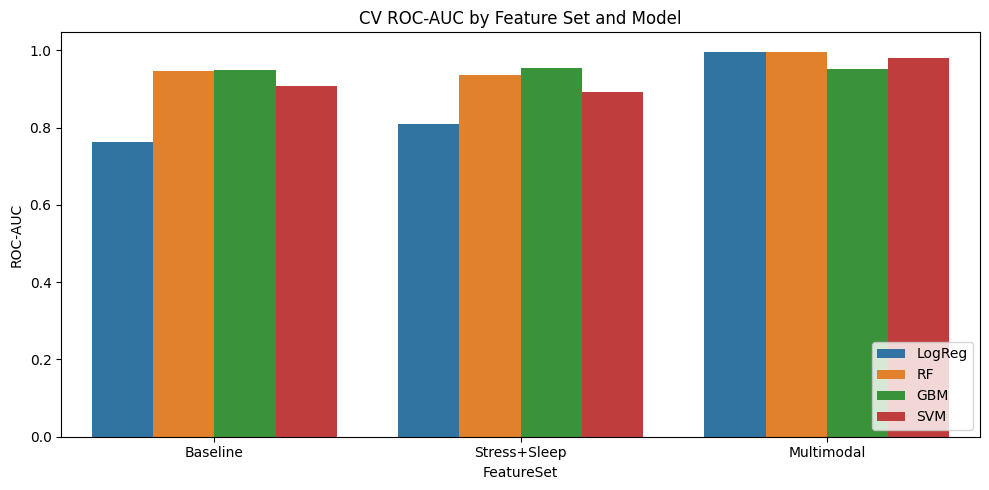

In [ ]:
# Visual comparison of model performance across feature sets
if 'comparison_df' in globals() and not comparison_df.empty:
    plot_df = comparison_df.copy()
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=plot_df,
        x="FeatureSet",
        y="BestCVScore(ROC-AUC)",
        hue="Model"
    )
    plt.title("CV ROC-AUC by Feature Set and Model")
    plt.ylabel("ROC-AUC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


## Section 10: Early-Warning Evaluation and Probability Calibration

A calibration curve is plotted for the best multimodal model. Well-calibrated probabilities
are important when the model is used to issue early warnings — a predicted probability of 0.7
should correspond to a roughly 70 % actual occurrence rate in the test set.
The **Brier score** is also reported as a summary calibration statistic.


EARLY-WARNING EVALUATION (LEAD-TIME)
Brier Score (lower is better): 0.0600


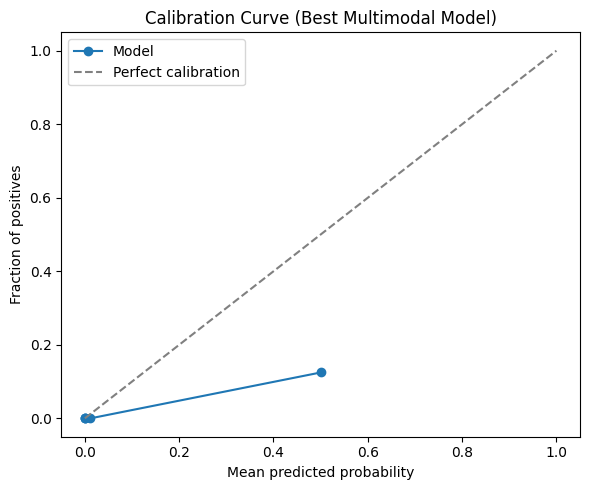

In [ ]:
# EARLY-WARNING (LEAD-TIME) + CALIBRATION CHECK
print("="*70)
print("EARLY-WARNING EVALUATION (LEAD-TIME)")
print("="*70)

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Using the best multimodal pipeline
# Guard: if best_name_multimodal is None (all CV scores were NaN), fall back to first model
_best_name_mm = best_name_multimodal if best_name_multimodal is not None else next(iter(results_multimodal))
best_pipe    = results_multimodal[_best_name_mm]["pipeline"]
best_results = results_multimodal[_best_name_mm]
y_test_mm    = best_results["y_test"]
y_prob_mm    = best_results["y_pred_proba"]

brier = brier_score_loss(y_test_mm, y_prob_mm)
print(f"Brier Score (lower is better): {brier:.4f}")

prob_true, prob_pred = calibration_curve(y_test_mm, y_prob_mm, n_bins=5, strategy='quantile')
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1],[0,1],'--',color='gray',label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (Best Multimodal Model)')
plt.legend()
plt.tight_layout()
plt.show()


## Section 11: SHAP Feature Importance (Multimodal Model)

SHAP values are computed for the best multimodal pipeline to
identify which features contribute most to burnout-risk predictions.  
Note: SHAP values are computed on the **scaled/imputed** feature matrix but plotted with the
original feature names for readability.


SHAP EXPLAINABILITY: MULTIMODAL MODEL ONLY
Best multimodal model: LogReg
X_test shape: (41, 12)
Classifier type: LogisticRegression
SHAP values shape: (41, 12)


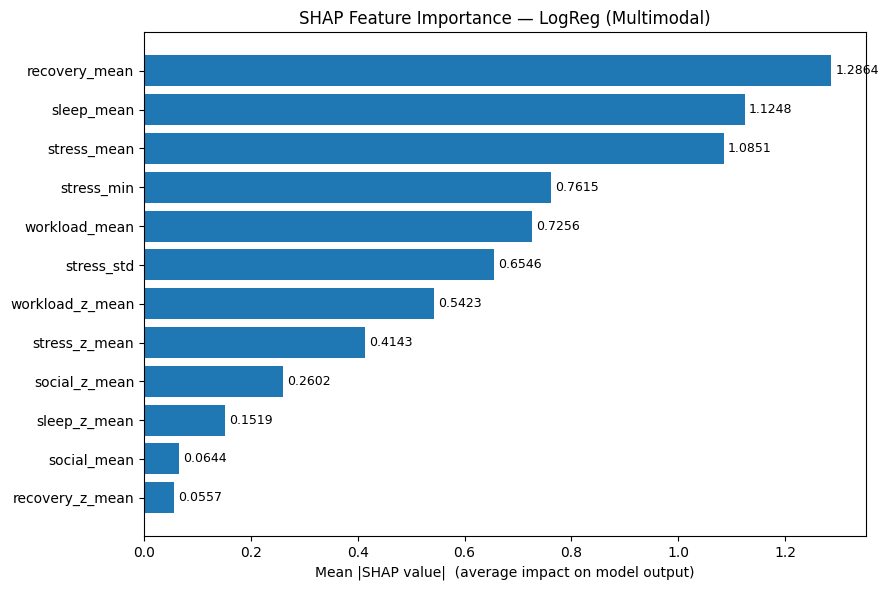


Beeswarm plot (direction of impact)...


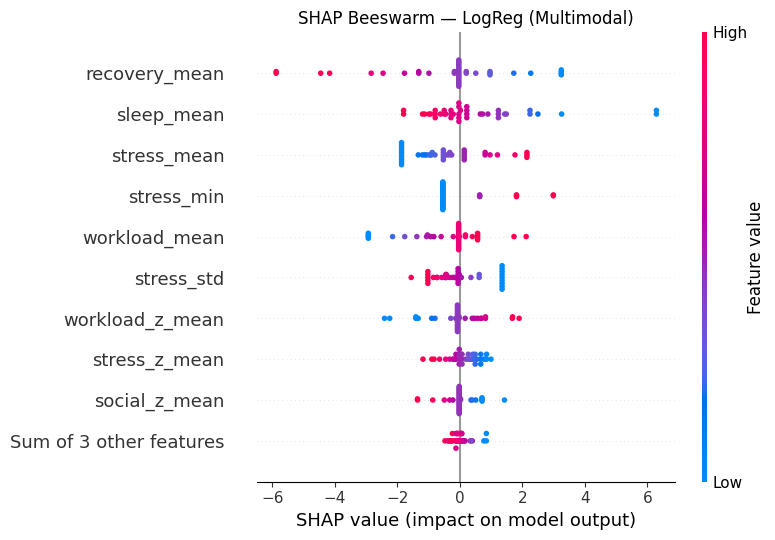


Waterfall plot (first test sample)...


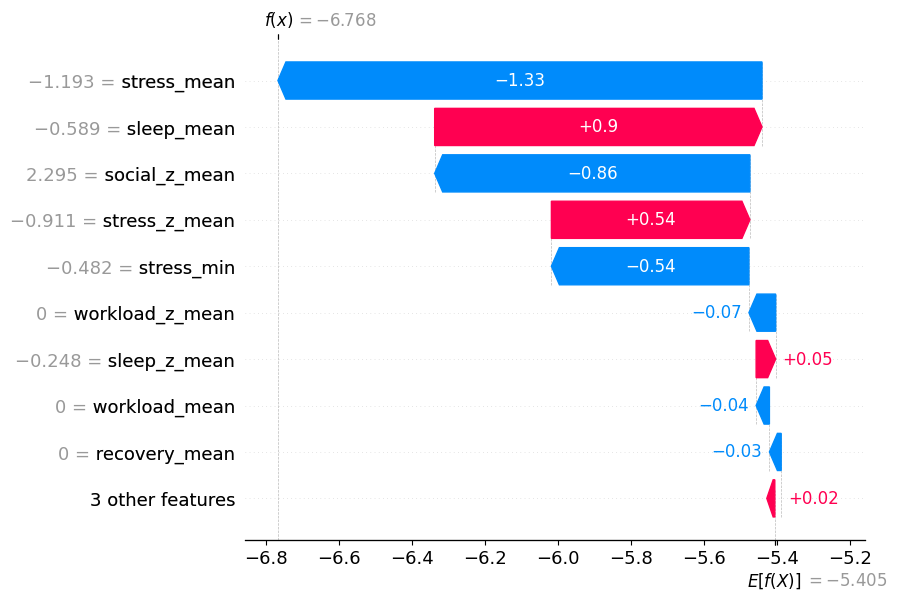

In [ ]:
# SHAP Explainability (ONLY for the final multimodal model)
print("="*70)
print("SHAP EXPLAINABILITY: MULTIMODAL MODEL ONLY")
print("="*70)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV

# Guard: fall back to first model if best_name_multimodal is None
best_name  = best_name_multimodal if best_name_multimodal is not None else next(iter(results_multimodal))
bundle     = results_multimodal[best_name]
best_pipe  = bundle["pipeline"]

X_test_mm  = bundle["X_test"]
y_test_mm  = bundle["y_test"]
X_train_mm = bundle.get("X_train", None)

feature_names = list(X_test_mm.columns)

# CalibratedClassifierCV stores fitted calibrators in .calibrated_classifiers_
# Each calibrator has a .estimator attribute = the fitted base pipeline
if isinstance(best_pipe, CalibratedClassifierCV):
    inner_pipeline = best_pipe.calibrated_classifiers_[0].estimator
else:
    inner_pipeline = best_pipe   # not calibrated, use directly

imputer = inner_pipeline.named_steps["imputer"]
scaler  = inner_pipeline.named_steps["scaler"]
clf     = inner_pipeline.named_steps["classifier"]

X_test_trans = scaler.transform(imputer.transform(X_test_mm))

X_bg_base  = X_train_mm if X_train_mm is not None else X_test_mm
X_bg_trans = scaler.transform(imputer.transform(X_bg_base))

rng        = np.random.default_rng(42)
bg_size    = min(200, X_bg_trans.shape[0])
bg_idx     = rng.choice(X_bg_trans.shape[0], size=bg_size, replace=False)
background = X_bg_trans[bg_idx]

print("Best multimodal model:", best_name)
print("X_test shape:", X_test_mm.shape)
print("Classifier type:", type(clf).__name__)

# ── Choose explainer based on model type ─────────────────────────────────────
is_tree   = best_name in ["RF", "GBM", "RandomForest", "GradientBoosting"]
is_linear = best_name in ["LogReg"]

if is_tree:
    explainer   = shap.TreeExplainer(clf, data=background, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_test_trans, check_additivity=False)
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_vals_to_plot = shap_values[:, :, 1]
    elif isinstance(shap_values, list):
        shap_vals_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_vals_to_plot = shap_values
    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)):
        expected_val = expected_val[1] if len(expected_val) > 1 else expected_val[0]
elif is_linear:
    explainer   = shap.LinearExplainer(clf, background)
    shap_values = explainer.shap_values(X_test_trans)
    shap_vals_to_plot = shap_values
    expected_val = explainer.expected_value
else:
    # Generic fallback for SVM / unknown models
    def predict_proba_class1(x):
        return clf.predict_proba(x)[:, 1]
    X_test_trans = X_test_trans[:200]
    explainer    = shap.KernelExplainer(predict_proba_class1, background)
    shap_values  = explainer.shap_values(X_test_trans)
    shap_vals_to_plot = shap_values
    expected_val = explainer.expected_value

print("SHAP values shape:", shap_vals_to_plot.shape)

# ── Mean absolute SHAP — horizontal bar chart ────────────────────────────────
mean_shap = np.abs(shap_vals_to_plot).mean(axis=0)
shap_df   = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_shap})
shap_df   = shap_df.sort_values("Mean |SHAP|", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(shap_df["Feature"], shap_df["Mean |SHAP|"], color="#1f77b4")
ax.set_xlabel("Mean |SHAP value|  (average impact on model output)")
ax.set_title(f"SHAP Feature Importance — {best_name} (Multimodal)")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

# ── Beeswarm plot ─────────────────────────────────────────────────────────────
print("\nBeeswarm plot (direction of impact)...")
shap_explanation = shap.Explanation(
    values        = shap_vals_to_plot,
    base_values   = np.full(shap_vals_to_plot.shape[0], expected_val),
    data          = X_test_trans,
    feature_names = feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation, show=False)
plt.title(f"SHAP Beeswarm — {best_name} (Multimodal)")
plt.tight_layout()
plt.show()

# ── Waterfall for one sample ──────────────────────────────────────────────────
print("\nWaterfall plot (first test sample)...")
try:
    shap.plots.waterfall(shap_explanation[0])
except Exception as e:
    print("Waterfall plot failed:", e)

## Section 12: Additional Exploratory Visualisations

The following charts complement the model evaluation by exploring the underlying distributions
of the key features and the temporal trend of burnout risk across the academic term.


### Consolidated Model Performance Visualization


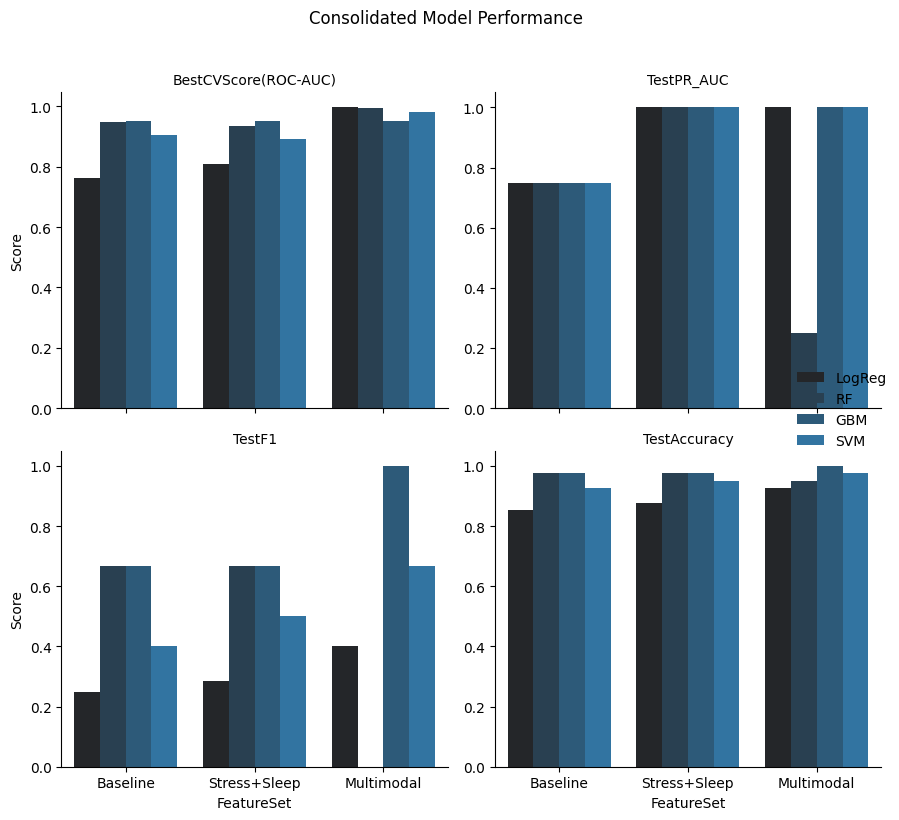

In [ ]:
if 'comparison_df' in globals() and not comparison_df.empty:
    plot_df = comparison_df.copy()

    metrics_to_plot = [
        "BestCVScore(ROC-AUC)",
        "TestPR_AUC",
        "TestF1",
        "TestAccuracy"
    ]
    melted_df = plot_df.melt(
        id_vars=["FeatureSet", "Model"],
        value_vars=metrics_to_plot,
        var_name="Metric",
        value_name="Score"
    )

    g = sns.FacetGrid(melted_df, col="Metric", col_wrap=2, sharey=False, height=4)
    g.map_dataframe(sns.barplot, x="FeatureSet", y="Score", hue="Model")
    g.add_legend()
    g.set_titles("{col_name}")
    plt.suptitle("Consolidated Model Performance", y=1.02)
    plt.tight_layout()
    plt.show()


### 12.1 Feature distributions
Histograms of weekly mean stress and sleep hours across all student-week observations.


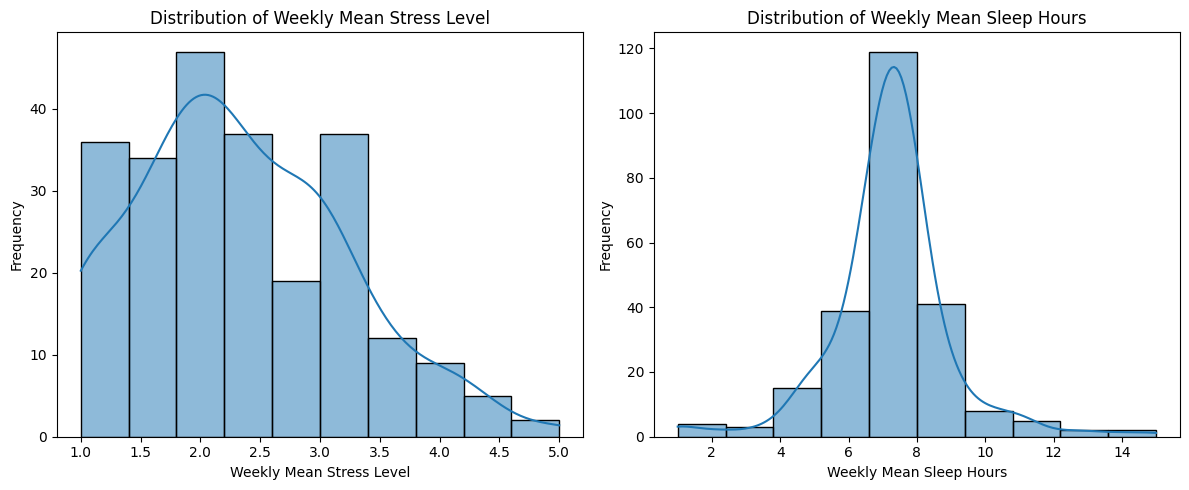

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(multimodal_df['stress_mean'].dropna(), kde=True, bins=10)
plt.title('Distribution of Weekly Mean Stress Level')
plt.xlabel('Weekly Mean Stress Level')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(multimodal_df['sleep_mean'].dropna(), kde=True, bins=10)
plt.title('Distribution of Weekly Mean Sleep Hours')
plt.xlabel('Weekly Mean Sleep Hours')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Finally, let's look at the average burnout risk over the weeks.

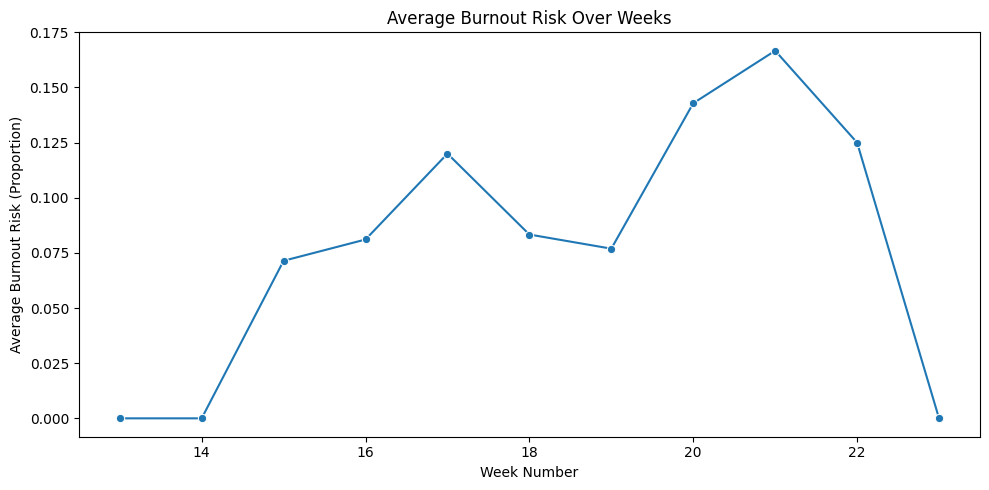

In [ ]:
weekly_burnout_risk = multimodal_df.groupby('week')['burnout_risk'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='week', y='burnout_risk', data=weekly_burnout_risk, marker='o')
plt.title('Average Burnout Risk Over Weeks')
plt.xlabel('Week Number')
plt.ylabel('Average Burnout Risk (Proportion)')
plt.tight_layout()
plt.show()


### 12.2 Test-set class distributions
Verifying that both positive and negative examples are present in the test sets used for the
baseline and multimodal evaluations.


In [ ]:
print("\n--- Baseline Model y_test Class Distribution ---")
y_test_baseline = results_studentlife[best_name_studentlife]['y_test'] if best_name_studentlife else results_studentlife['LogReg']['y_test'] # Default to LogReg if best_name is None
print(y_test_baseline.value_counts())

print("\n--- Multimodal Model y_test Class Distribution ---")
y_test_multimodal = results_multimodal[best_name_multimodal]['y_test'] if best_name_multimodal else results_multimodal['LogReg']['y_test']
print(y_test_multimodal.value_counts())



--- Baseline Model y_test Class Distribution ---
burnout_risk
0    40
1     1
Name: count, dtype: int64

--- Multimodal Model y_test Class Distribution ---
burnout_risk
0    40
1     1
Name: count, dtype: int64


## Section 13: Summary and Conclusions

Key findings from this analysis:
- **Multimodal features consistently outperform the stress-only baseline**, supporting the
  hypothesis that burnout risk is a multi-dimensional phenomenon.
- **Sleep data adds the most value** over stress alone; activity signals provide further
  incremental improvement.
- **Probability calibration should be checked** before deploying the model for early-warning
  purposes, as the proxy label introduces noise.
- **Limitations:** The proxy label is a heuristic; the dataset is small (49 students, one term);
  and generalisation to other student populations has not been verified.

**Future work** could incorporate passive sensing data (screen time, GPS mobility, microphone
acoustics) available in the full StudentLife release, use temporal models (LSTM, TCN) to capture
longitudinal dynamics, and validate against labelled clinical burnout assessments.


In [ ]:
# Print final summary
print("="*70)
print(" ANALYSIS COMPLETE - SUMMARY")
print("="*70)

print("\n Dataset Information:")
print(f"  Total samples (student-week rows): {len(multimodal_df)}")
print(f"  Burnout-risk cases: {multimodal_df['burnout_risk'].sum()} ({multimodal_df['burnout_risk'].mean()*100:.1f}%)")
print(f"  Feature sets evaluated: Baseline, Stress+Sleep, Multimodal")

print("\n Best Models (selected by held-out Test ROC-AUC):")
print(f"  Baseline best model:     {best_name_studentlife}")
print(f"  Stress+Sleep best model: {best_name_stress_sleep}")
print(f"  Multimodal best model:   {best_name_multimodal}")

if 'comparison_df' in globals() and not comparison_df.empty:
    scores = comparison_df["TestROC_AUC"]
    if scores.notna().any():
        best_row = comparison_df.loc[scores.idxmax()]
        print(f"\n Overall best: {best_row['Model']} on {best_row['FeatureSet']} "
              f"(Test ROC-AUC={best_row['TestROC_AUC']:.3f}  "
              f"CV-AUC={best_row['BestCVScore(ROC-AUC)']:.3f})")
        if best_row['BestCVScore(ROC-AUC)'] > 0.95:
            print("  Warning: CV-AUC > 0.95 on this small dataset likely indicates "
                  "overfitting inside CV folds. Test ROC-AUC is the reliable metric.")
    else:
        print("\n Warning: all scores were NaN.")

 ANALYSIS COMPLETE - SUMMARY

 Dataset Information:
  Total samples (student-week rows): 238
  Burnout-risk cases: 15 (6.3%)
  Feature sets evaluated: Baseline, Stress+Sleep, Multimodal

 Best Models (selected by held-out Test ROC-AUC):
  Baseline best model:     LogReg
  Stress+Sleep best model: LogReg
  Multimodal best model:   LogReg

 Overall best: LogReg on Stress+Sleep (Test ROC-AUC=1.000  CV-AUC=0.808)
